# 🚚 Résolution TSP avec GLOP (OR-Tools)

Implémentation du **Problème du Voyageur de Commerce (TSP)** via le solveur linéaire **GLOP** de Google OR-Tools.

### Approche : Formulation Miller-Tucker-Zemlin (MTZ)
Le TSP est formulé comme un **Programme Linéaire en Nombres Entiers (ILP)** :
- Variables binaires $x_{ij} \in \{0,1\}$ : l'arc $(i,j)$ est-il emprunté ?
- Variables de position $u_i$ : ordre de visite du nœud $i$ (contraintes MTZ anti-sous-tours)

$$\min \sum_{i} \sum_{j \neq i} d_{ij} \cdot x_{ij}$$

Sous contraintes :
- Chaque ville est visitée exactement une fois (entrée et sortie)
- Contraintes MTZ : $u_i - u_j + n \cdot x_{ij} \leq n-1$ (élimination des sous-tours)


## 1. Installation des dépendances

In [29]:
# Installation si nécessaire
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

try:
    from ortools.linear_solver import pywraplp
    print('✅ OR-Tools déjà installé')
except ImportError:
    print('📦 Installation de OR-Tools...')
    install('ortools')
    from ortools.linear_solver import pywraplp
    print('✅ OR-Tools installé')

try:
    import matplotlib.pyplot as plt
    print('✅ Matplotlib déjà installé')
except ImportError:
    install('matplotlib')
    import matplotlib.pyplot as plt

✅ OR-Tools déjà installé
✅ Matplotlib déjà installé


## 2. Données du problème

In [30]:
import json
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path

# ── Chargement du fichier dataset ───────────────────────────────────────────
DATASET_PATH = 'datasets/tsptwd_n10.json'  # ← modifier ici le nom du fichier

path = Path(DATASET_PATH)
if not path.exists():
    raise FileNotFoundError(
        f"Fichier '{DATASET_PATH}' introuvable.\n"
        f"Fichiers disponibles dans datasets/ : {list(Path('datasets').glob('*.json'))}"
    )

with open(path, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

print(f"📂 Dataset chargé : {path}")
if 'meta' in raw_data:
    m = raw_data['meta']
    print(f"   Clients : {m.get('n_clients','?')}  |  "
          f"Horizon : {m.get('horizon','?')}  |  "
          f"Seed : {m.get('seed','?')}")

# ── Construction de la liste unifiée de nœuds ────────────────────────────────
nodes = [raw_data['depot']] + raw_data['clients']
n = len(nodes)

scale = raw_data.get('meta', {}).get('scale', 1.0)

ids  = [nd['id']  for nd in nodes]
noms = [nd['nom'] for nd in nodes]
xs   = np.array([nd['x'] for nd in nodes]) * scale
ys   = np.array([nd['y'] for nd in nodes]) * scale

print(f"\nNombre de nœuds : {n}  (1 dépôt + {n-1} clients)")
print(f"{'ID':>4}  {'Nom':<12}  {'x':>8}  {'y':>8}")
print('-' * 38)
for i in range(n):
    print(f"{ids[i]:>4}  {noms[i]:<12}  {xs[i]:>8.4f}  {ys[i]:>8.4f}")


📂 Dataset chargé : datasets\tsptwd_n10.json
   Clients : 10  |  Horizon : 1440.0  |  Seed : 42

Nombre de nœuds : 11  (1 dépôt + 10 clients)
  ID  Nom                  x         y
--------------------------------------
   0  Dépôt         168.8844  151.5909
   1  Ville 1        84.1143   51.7834
   2  Ville 2       102.2549   80.9868
   3  Ville 3       156.7597   60.6625
   4  Ville 4        95.3194  116.6764
   5  Ville 5       181.6226  100.9374
   6  Ville 6        56.3676  151.1608
   7  Ville 7       123.6738   50.1013
   8  Ville 8       181.9493  196.5571
   9  Ville 9       162.0434  180.4332
  10  Ville 10       62.0295  145.9663


## 3. Matrice des distances euclidiennes

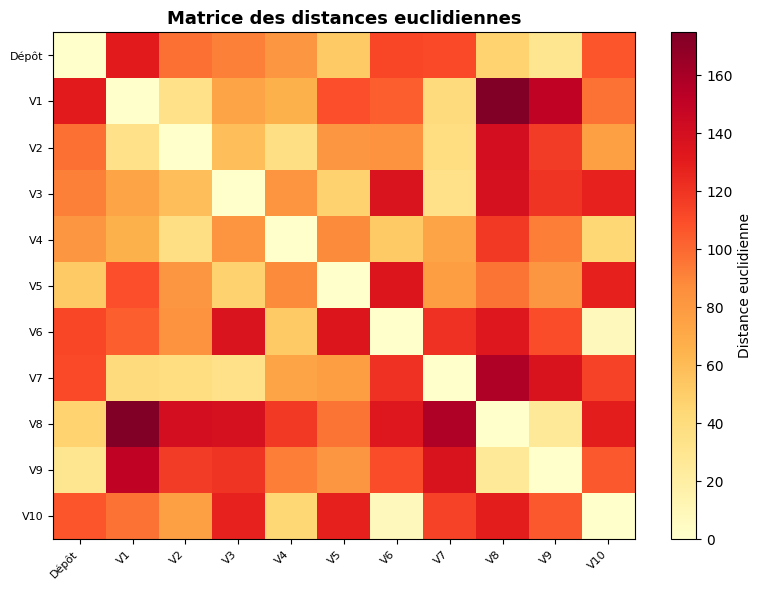


Distance moyenne : 91.8103
Distance max     : 174.7315


In [31]:
def euclidean(i, j):
    """Distance euclidienne entre les nœuds i et j (indices locaux 0..n-1)"""
    return math.sqrt((xs[i] - xs[j])**2 + (ys[i] - ys[j])**2)

# Matrice n×n
dist = [[euclidean(i, j) if i != j else 0.0 for j in range(n)] for i in range(n)]

# Affichage sous forme de heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(dist, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='Distance euclidienne')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([nd['nom'].replace('Ville ', 'V') for nd in nodes], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([nd['nom'].replace('Ville ', 'V') for nd in nodes], fontsize=8)
ax.set_title('Matrice des distances euclidiennes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nDistance moyenne : {np.mean([dist[i][j] for i in range(n) for j in range(n) if i!=j]):.4f}")
print(f"Distance max     : {max(dist[i][j] for i in range(n) for j in range(n) if i!=j):.4f}")

## 4. Formulation ILP – GLOP (OR-Tools)

### Formulation MTZ (Miller-Tucker-Zemlin)

**Variables :**
- $x_{ij} \in \{0,1\}$ : 1 si l'arc $(i \to j)$ est dans la tournée
- $u_i \in [1, n-1]$ : position de la ville $i$ dans la tournée (pour les clients)

**Objectif :** $\min \sum_{i,j} d_{ij} x_{ij}$

**Contraintes :**
1. Chaque ville a exactement 1 arc entrant : $\sum_i x_{ij} = 1 \; \forall j$
2. Chaque ville a exactement 1 arc sortant : $\sum_j x_{ij} = 1 \; \forall i$  
3. Anti-sous-tours (MTZ) : $u_i - u_j + n \cdot x_{ij} \leq n-1 \; \forall i,j \neq 0, i \neq j$

In [32]:
from ortools.linear_solver import pywraplp
import time

def solve_tsp_glop_mtz(dist, n, noms):
    """
    Résout le TSP via ILP (formulation MTZ) avec le solveur SCIP d'OR-Tools.
    GLOP résout la relaxation LP ; SCIP gère les variables entières.
    Retourne aussi un dictionnaire détaillé des temps par phase.
    """
    timings = {}  # mesures par phase

    # ── Init solveur ──────────────────────────────────────────────────────────
    t_phase = time.perf_counter()
    solver = pywraplp.Solver.CreateSolver('SCIP')
    if not solver:
        raise RuntimeError("Solveur SCIP non disponible")
    timings['init_solveur'] = time.perf_counter() - t_phase

    print("🔧 Solveur : SCIP (Branch-and-Bound + GLOP pour relaxations LP)")
    print(f"   Nœuds : {n}  |  Variables binaires : {n*n}  |  Contraintes MTZ : {(n-1)*(n-2)}")

    # ── Variables ─────────────────────────────────────────────────────────────
    t_phase = time.perf_counter()
    x = {}
    for i in range(n):
        for j in range(n):
            if i != j:
                x[i, j] = solver.BoolVar(f'x_{i}_{j}')
    u = {}
    for i in range(1, n):
        u[i] = solver.IntVar(1, n - 1, f'u_{i}')
    timings['creation_variables'] = time.perf_counter() - t_phase

    # ── Contraintes ───────────────────────────────────────────────────────────
    t_phase = time.perf_counter()
    for j in range(n):
        solver.Add(solver.Sum([x[i, j] for i in range(n) if i != j]) == 1)
    for i in range(n):
        solver.Add(solver.Sum([x[i, j] for j in range(n) if i != j]) == 1)
    for i in range(1, n):
        for j in range(1, n):
            if i != j:
                solver.Add(u[i] - u[j] + n * x[i, j] <= n - 1)
    timings['ajout_contraintes'] = time.perf_counter() - t_phase

    # ── Objectif ──────────────────────────────────────────────────────────────
    t_phase = time.perf_counter()
    objective = solver.Objective()
    for i in range(n):
        for j in range(n):
            if i != j:
                objective.SetCoefficient(x[i, j], dist[i][j])
    objective.SetMinimization()
    timings['def_objectif'] = time.perf_counter() - t_phase

    # ── Résolution ────────────────────────────────────────────────────────────
    print("\n⏳ Résolution en cours...")
    solver.SetTimeLimit(300_000)  # ← ici, en millisecondes
    t_phase = time.perf_counter()
    t_wall_start = time.time()
    status = solver.Solve()
    t_phase = time.perf_counter()
    t_wall_start = time.time()
    status = solver.Solve()
    timings['resolution'] = time.perf_counter() - t_phase
    elapsed = time.time() - t_wall_start

    # ── Extraction ────────────────────────────────────────────────────────────
    t_phase = time.perf_counter()
    if status == pywraplp.Solver.OPTIMAL:
        print(f"\n✅ Solution OPTIMALE trouvée en {elapsed:.4f}s")
        print(f"   Distance totale optimale : {solver.Objective().Value():.6f}")

        arcs = [(i, j) for i in range(n) for j in range(n)
                if i != j and x[i, j].solution_value() > 0.5]
        tour = [0]
        current = 0
        while True:
            next_node = next(j for (i, j) in arcs if i == current)
            if next_node == 0:
                break
            tour.append(next_node)
            current = next_node
        tour.append(0)
        timings['extraction_solution'] = time.perf_counter() - t_phase
        timings['TOTAL'] = sum(timings.values())

        return {
            'status': 'OPTIMAL',
            'distance': solver.Objective().Value(),
            'tour': tour,
            'time': elapsed,
            'timings': timings,
            'n_vars': solver.NumVariables(),
            'n_constraints': solver.NumConstraints()
        }
    else:
        print(f"\nStop à {elapsed:.4f}s")
        print(f"   Distance totale optimale : {solver.Objective().Value():.6f}")
        status_str = {0: 'OPTIMAL', 1: 'FEASIBLE', 2: 'INFEASIBLE',
                      3: 'UNBOUNDED', 4: 'ABNORMAL', 6: 'NOT_SOLVED'}.get(status, f'UNKNOWN({status})')
        print(f"❌ Pas de solution optimale. Statut : {status_str}")
        arcs = [(i, j) for i in range(n) for j in range(n)
                if i != j and x[i, j].solution_value() > 0.5]
        tour = [0]
        current = 0
        while True:
            next_node = next(j for (i, j) in arcs if i == current)
            if next_node == 0:
                break
            tour.append(next_node)
            current = next_node
        tour.append(0)
        timings['extraction_solution'] = time.perf_counter() - t_phase
        timings['TOTAL'] = sum(timings.values())
        return {
            'status': status_str,
            'distance': solver.Objective().Value(),
            'tour': tour,
            'time': elapsed,
            'timings': timings,
            'n_vars': solver.NumVariables(),
            'n_constraints': solver.NumConstraints()
        }


# ── Lancement ────────────────────────────────────────────────────────────────
result = solve_tsp_glop_mtz(dist, n, noms)

🔧 Solveur : SCIP (Branch-and-Bound + GLOP pour relaxations LP)
   Nœuds : 11  |  Variables binaires : 121  |  Contraintes MTZ : 90

⏳ Résolution en cours...

✅ Solution OPTIMALE trouvée en 0.0000s
   Distance totale optimale : 478.746353


## 5. ⏱️ Analyse détaillée des temps de calcul

╔══════════════════════════════════════════════════════╗
║    PROFIL TEMPOREL DE RÉSOLUTION  (perf_counter)     ║
╠══════════════════════════════════════════════════════╣
  Phase                        Durée (ms)       %
  ────────────────────────────────────────────────
  Init solveur                     1.9820   35.2%  ███████████
  Création variables               1.8934   33.6%  ███████████
  Ajout contraintes                1.5072   26.8%  ████████
  Def. objectif                    0.0488    0.9%  
  Résolution (SCIP/GLOP)           0.0481    0.9%  
  Extraction solution              0.1535    2.7%  
  ────────────────────────────────────────────────
  TOTAL mesuré                     5.6330  100.0%
  Temps mur (time.time)            0.0484  ms
╚══════════════════════════════════════════════════════╝


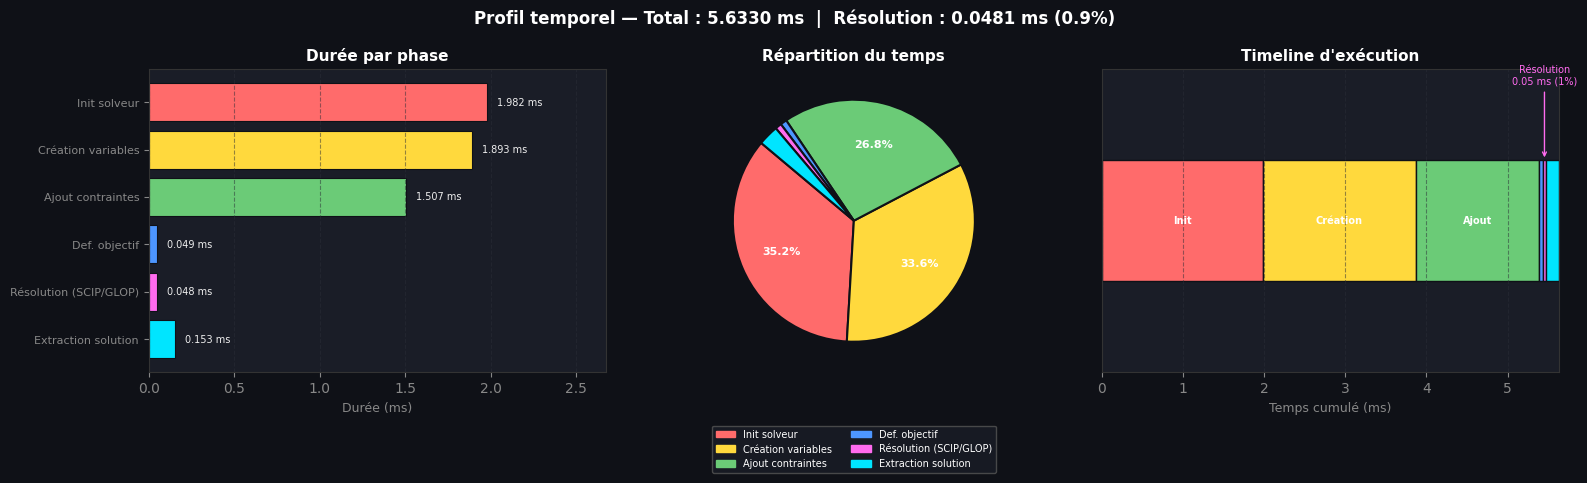


💡 La phase de résolution (SCIP/GLOP) représente 0.9% du temps total.


In [33]:
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

if result:
    t = result['timings']
    phases = ['init_solveur', 'creation_variables', 'ajout_contraintes',
              'def_objectif', 'resolution', 'extraction_solution']
    labels = [
        'Init solveur',
        'Création variables',
        'Ajout contraintes',
        'Def. objectif',
        'Résolution (SCIP/GLOP)',
        'Extraction solution'
    ]
    durations = [t[p] * 1000 for p in phases]  # en millisecondes
    total_ms = sum(durations)

    # ── Rapport texte ─────────────────────────────────────────────────────────
    print("╔" + "═"*54 + "╗")
    print("║    PROFIL TEMPOREL DE RÉSOLUTION  (perf_counter)     ║")
    print("╠" + "═"*54 + "╣")
    print(f"  {'Phase':<28} {'Durée (ms)':>10}  {'%':>6}")
    print("  " + "─"*48)
    for label, dur in zip(labels, durations):
        pct = dur / total_ms * 100
        bar = '█' * int(pct / 3)
        print(f"  {label:<28} {dur:>10.4f}  {pct:>5.1f}%  {bar}")
    print("  " + "─"*48)
    print(f"  {'TOTAL mesuré':<28} {total_ms:>10.4f}  100.0%")
    print(f"  {'Temps mur (time.time)':<28} {result['time']*1000:>10.4f}  ms")
    print("╚" + "═"*54 + "╝")

    # ── Figure 3 panneaux ─────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 5), facecolor='#0f1117')
    ax1 = fig.add_subplot(131)  # barres horizontales
    ax2 = fig.add_subplot(132)  # camembert
    ax3 = fig.add_subplot(133)  # timeline Gantt

    for ax in [ax1, ax2, ax3]:
        ax.set_facecolor('#1a1d27')

    palette = ['#ff6b6b', '#ffd93d', '#6bcb77', '#4d96ff', '#ff6bef', '#00e5ff']

    # ── Panneau 1 : Barres horizontales ───────────────────────────────────────
    y_pos = range(len(phases))
    bars = ax1.barh(y_pos, durations, color=palette, edgecolor='#0f1117', linewidth=0.8)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(labels, fontsize=8, color='#ccc')
    ax1.set_xlabel('Durée (ms)', color='#888', fontsize=9)
    ax1.set_title('Durée par phase', color='white', fontsize=11, fontweight='bold')
    ax1.tick_params(colors='#888')
    ax1.grid(True, axis='x', color='#2a2d37', linestyle='--', alpha=0.5)
    for spine in ax1.spines.values():
        spine.set_edgecolor('#333')
    for bar, dur in zip(bars, durations):
        ax1.text(bar.get_width() + total_ms * 0.01, bar.get_y() + bar.get_height()/2,
                 f'{dur:.3f} ms', va='center', color='#eee', fontsize=7)
    ax1.set_xlim(0, max(durations) * 1.35)
    ax1.invert_yaxis()

    # ── Panneau 2 : Camembert ─────────────────────────────────────────────────
    wedge_labels = [f'{d/total_ms*100:.1f}%' if d/total_ms > 0.03 else '' for d in durations]
    wedges, texts = ax2.pie(
        durations, labels=None, colors=palette,
        startangle=140, wedgeprops=dict(edgecolor='#0f1117', linewidth=1.5)
    )
    for i, (w, pct_label) in enumerate(zip(wedges, wedge_labels)):
        if pct_label:
            angle = (w.theta1 + w.theta2) / 2
            x = 0.65 * np.cos(np.radians(angle))
            y = 0.65 * np.sin(np.radians(angle))
            ax2.text(x, y, pct_label, ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax2.set_title('Répartition du temps', color='white', fontsize=11, fontweight='bold')
    legend_patches = [mpatches.Patch(color=palette[i], label=labels[i]) for i in range(len(phases))]
    ax2.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.35),
               fontsize=7, facecolor='#1a1d27', edgecolor='#555', labelcolor='white', ncol=2)

    # ── Panneau 3 : Timeline Gantt ────────────────────────────────────────────
    starts = [sum(durations[:i]) for i in range(len(durations))]
    for i, (start, dur, label, color) in enumerate(zip(starts, durations, labels, palette)):
        ax3.barh(0, dur, left=start, color=color, edgecolor='#0f1117', linewidth=1, height=0.4)
        if dur / total_ms > 0.04:
            ax3.text(start + dur/2, 0, label.split()[0], ha='center', va='center',
                     fontsize=7, color='white', fontweight='bold')
    ax3.set_yticks([])
    ax3.set_xlabel('Temps cumulé (ms)', color='#888', fontsize=9)
    ax3.set_title('Timeline d\'exécution', color='white', fontsize=11, fontweight='bold')
    ax3.tick_params(colors='#888')
    ax3.set_xlim(0, total_ms)
    ax3.set_ylim(-0.5, 0.5)
    for spine in ax3.spines.values():
        spine.set_edgecolor('#333')
    ax3.grid(True, axis='x', color='#2a2d37', linestyle='--', alpha=0.5)

    # Annotation du temps de résolution
    res_start = starts[4]
    res_dur = durations[4]
    ax3.annotate(
        f'Résolution\n{res_dur:.2f} ms ({res_dur/total_ms*100:.0f}%)',
        xy=(res_start + res_dur/2, 0.2),
        xytext=(res_start + res_dur/2, 0.45),
        color='#ff6bef', fontsize=7, ha='center',
        arrowprops=dict(arrowstyle='->', color='#ff6bef', lw=1)
    )

    plt.suptitle(
        f'Profil temporel — Total : {total_ms:.4f} ms  |  '
        f'Résolution : {durations[4]:.4f} ms ({durations[4]/total_ms*100:.1f}%)',
        color='white', fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    print(f"\n💡 La phase de résolution (SCIP/GLOP) représente "
          f"{durations[4]/total_ms*100:.1f}% du temps total.")

## 6. Résultats détaillés

In [34]:
if result:
    tour = result['tour']

    print("═" * 55)
    print("  RAPPORT DE RÉSOLUTION TSP – GLOP/SCIP (OR-Tools)")
    print("═" * 55)
    print(f"  Statut          : {result['status']}")
    print(f"  Variables       : {result['n_vars']}")
    print(f"  Contraintes     : {result['n_constraints']}")
    print(f"  Temps résolution: {result['time']:.3f} s")
    print(f"  Distance totale : {result['distance']:.6f} unités")
    print("─" * 55)
    print("  TOURNÉE OPTIMALE")
    print("─" * 55)

    total = 0
    for step in range(len(tour) - 1):
        i, j = tour[step], tour[step + 1]
        d = dist[i][j]
        total += d
        arrow = "→"
        print(f"  {step+1:>2}. {noms[i]:<12} {arrow} {noms[j]:<12}  ({d:.4f})")

    print("─" * 55)
    print(f"  TOTAL : {total:.6f}")
    print("═" * 55)

═══════════════════════════════════════════════════════
  RAPPORT DE RÉSOLUTION TSP – GLOP/SCIP (OR-Tools)
═══════════════════════════════════════════════════════
  Statut          : OPTIMAL
  Variables       : 120
  Contraintes     : 112
  Temps résolution: 0.000 s
  Distance totale : 478.746353 unités
───────────────────────────────────────────────────────
  TOURNÉE OPTIMALE
───────────────────────────────────────────────────────
   1. Dépôt        → Ville 5       (52.2306)
   2. Ville 5      → Ville 3       (47.3310)
   3. Ville 3      → Ville 7       (34.7307)
   4. Ville 7      → Ville 1       (39.5952)
   5. Ville 1      → Ville 2       (34.3791)
   6. Ville 2      → Ville 4       (36.3572)
   7. Ville 4      → Ville 10      (44.3409)
   8. Ville 10     → Ville 6       (7.6838)
   9. Ville 6      → Ville 9       (109.6552)
  10. Ville 9      → Ville 8       (25.6168)
  11. Ville 8      → Dépôt         (46.8258)
───────────────────────────────────────────────────────
  TOTAL : 478

## 7. Visualisation de la tournée optimale

In [35]:
if result:
    tour = result['tour']

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.patch.set_facecolor('#0f1117')

    for ax in axes:
        ax.set_facecolor('#1a1d27')
        ax.tick_params(colors='#888')
        for spine in ax.spines.values():
            spine.set_edgecolor('#333')

    # ── Graphe gauche : Tous les arcs possibles vs tournée optimale ──────────
    ax = axes[0]
    ax.set_title('Tournée optimale TSP', color='white', fontsize=13, fontweight='bold', pad=12)

    # Arcs de la tournée
    cmap = plt.cm.plasma
    n_arcs = len(tour) - 1
    for step in range(n_arcs):
        i, j = tour[step], tour[step + 1]
        color = cmap(step / n_arcs)
        ax.annotate("",
            xy=(xs[j], ys[j]), xytext=(xs[i], ys[i]),
            arrowprops=dict(arrowstyle='->', color=color, lw=2.2, shrinkA=10, shrinkB=10)
        )

    # Nœuds clients
    for i in range(1, n):
        ax.scatter(xs[i], ys[i], s=120, c='#4fc3f7', zorder=5, edgecolors='white', linewidths=1)
        ax.text(xs[i] + 0.015, ys[i] + 0.015, noms[i].replace('Ville ', 'V'),
                color='#e0e0e0', fontsize=8, fontweight='bold')

    # Dépôt
    ax.scatter(xs[0], ys[0], s=250, c='#ff7043', zorder=6, marker='*',
               edgecolors='white', linewidths=1.5)
    ax.text(xs[0] + 0.015, ys[0] + 0.015, noms[0], color='#ff7043',
            fontsize=9, fontweight='bold')

    # Numérotation des étapes
    for step in range(len(tour) - 1):
        i = tour[step]
        mx = (xs[i] + xs[tour[step+1]]) / 2
        my = (ys[i] + ys[tour[step+1]]) / 2
        ax.text(mx, my, str(step+1), color='yellow', fontsize=7,
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.1', fc='#1a1d27', ec='none', alpha=0.7))

    legend_elements = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#ff7043',
               markersize=14, label='Dépôt', linestyle='None'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#4fc3f7',
               markersize=8, label='Client', linestyle='None'),
    ]
    ax.legend(handles=legend_elements, loc='lower right',
              facecolor='#1a1d27', edgecolor='#555', labelcolor='white', fontsize=9)
    ax.set_xlim(-0.05, 1.1)
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel('x', color='#888')
    ax.set_ylabel('y', color='#888')
    ax.grid(True, color='#2a2d37', linestyle='--', alpha=0.5)

    # ── Graphe droit : distances cumulées par étape ───────────────────────────
    ax2 = axes[1]
    ax2.set_title('Distance cumulée par étape', color='white', fontsize=13, fontweight='bold', pad=12)

    cumul = [0]
    step_labels = [noms[tour[0]]]
    for step in range(len(tour) - 1):
        i, j = tour[step], tour[step + 1]
        cumul.append(cumul[-1] + dist[i][j])
        step_labels.append(noms[tour[step+1]])

    step_labels_short = [s.replace('Ville ', 'V') for s in step_labels]

    colors_bar = [plt.cm.plasma(k / (len(cumul)-1)) for k in range(len(cumul)-1)]
    segs = [cumul[k+1] - cumul[k] for k in range(len(cumul)-1)]
    bars = ax2.bar(range(len(segs)), segs, color=colors_bar, edgecolor='#1a1d27', linewidth=0.5)

    for bar, val in zip(bars, segs):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', va='bottom', color='#ccc', fontsize=7)

    ax2.set_xticks(range(len(segs)))
    ax2.set_xticklabels(
        [f"{step_labels_short[k]}→{step_labels_short[k+1]}" for k in range(len(segs))],
        rotation=45, ha='right', fontsize=7, color='#aaa'
    )
    ax2.set_ylabel('Distance de l\'arc', color='#888')
    ax2.set_xlabel('Étape', color='#888')
    ax2.tick_params(colors='#888')
    ax2.grid(True, axis='y', color='#2a2d37', linestyle='--', alpha=0.5)

    # Ligne de distance totale
    ax2_twin = ax2.twinx()
    ax2_twin.set_facecolor('#1a1d27')
    ax2_twin.plot(range(len(cumul)-1), cumul[1:], color='#00e5ff',
                  linewidth=2, marker='o', markersize=4, label='Cumulé')
    ax2_twin.set_ylabel('Distance cumulée', color='#00e5ff')
    ax2_twin.tick_params(colors='#00e5ff')
    ax2_twin.spines['right'].set_edgecolor('#00e5ff')

    plt.suptitle(
        f'TSP Optimal  –  Distance = {result["distance"]:.4f}  |  Temps = {result["time"]:.3f}s',
        color='white', fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()
    print("\n📊 Graphique sauvegardé dans /tmp/tsp_result.png")

C:\Users\anton\AppData\Local\Temp\ipykernel_26164\2289937715.py:107: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


MemoryError: bad allocation

<Figure size 1600x700 with 3 Axes>


📊 Graphique sauvegardé dans /tmp/tsp_result.png


## 8. Analyse de la Relaxation LP (GLOP pur)

GLOP résout la **relaxation continue** du problème (les $x_{ij}$ sont réels entre 0 et 1).
On peut observer le **gap d'intégralité** : différence entre la borne LP et la solution entière.

In [36]:
def solve_lp_relaxation(dist, n):
    """Résout la relaxation LP du TSP avec GLOP (variables continues [0,1])"""
    solver = pywraplp.Solver.CreateSolver('GLOP')  # ← GLOP pur, pas de variables entières
    if not solver:
        raise RuntimeError("Solveur GLOP non disponible")

    # Variables CONTINUES x[i][j] ∈ [0, 1]
    x = {}
    for i in range(n):
        for j in range(n):
            if i != j:
                x[i, j] = solver.NumVar(0.0, 1.0, f'x_{i}_{j}')

    # Contraintes de degré (entrée)
    for j in range(n):
        solver.Add(solver.Sum([x[i, j] for i in range(n) if i != j]) == 1)

    # Contraintes de degré (sortie)
    for i in range(n):
        solver.Add(solver.Sum([x[i, j] for j in range(n) if i != j]) == 1)

    # NOTE : pas de contraintes MTZ ici (elles impliquent des variables entières)
    # → la relaxation LP est plus faible, donc borne inférieure

    # Objectif
    objective = solver.Objective()
    for i in range(n):
        for j in range(n):
            if i != j:
                objective.SetCoefficient(x[i, j], dist[i][j])
    objective.SetMinimization()

    t0 = time.time()
    status = solver.Solve()
    elapsed = time.time() - t0

    if status == pywraplp.Solver.OPTIMAL:
        lp_value = solver.Objective().Value()
        # Récupération des valeurs fractionnaires
        frac_arcs = [(i, j, x[i,j].solution_value())
                     for i in range(n) for j in range(n)
                     if i != j and 0.01 < x[i,j].solution_value() < 0.99]
        return lp_value, frac_arcs, elapsed
    return None, [], 0


print("🔷 Résolution de la relaxation LP avec GLOP...")
lp_value, frac_arcs, lp_time = solve_lp_relaxation(dist, n)

if lp_value and result:
    gap = (result['distance'] - lp_value) / lp_value * 100
    print(f"\n{'─'*45}")
    print(f"  Borne LP (GLOP)   : {lp_value:.6f}  ({lp_time:.3f}s)")
    print(f"  Solution ILP      : {result['distance']:.6f}  ({result['time']:.3f}s)")
    print(f"  Gap d'intégralité : {gap:.2f}%")
    print(f"  Arcs fractionnaires (LP) : {len(frac_arcs)}")
    print(f"{'─'*45}")

    if frac_arcs:
        print("\n  Arcs avec valeurs fractionnaires :")
        for i, j, v in sorted(frac_arcs, key=lambda t: -t[2]):
            print(f"    {noms[i]:<12} → {noms[j]:<12}  x = {v:.4f}")

🔷 Résolution de la relaxation LP avec GLOP...

─────────────────────────────────────────────
  Borne LP (GLOP)   : 364.019517  (0.001s)
  Solution ILP      : 478.746353  (0.000s)
  Gap d'intégralité : 31.52%
  Arcs fractionnaires (LP) : 0
─────────────────────────────────────────────


## 9. Synthèse : Rôle de GLOP dans la résolution

In [37]:
if result and lp_value:
    print("""
╔══════════════════════════════════════════════════════════════════╗
║           COMMENT GLOP INTERVIENT DANS CE TSP                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  GLOP (solveur LP) est utilisé à DEUX niveaux :                  ║
║                                                                  ║
║  1. RELAXATION LP (politique GLOBALE)                            ║
║     → Résout le problème sans contrainte d'intégralité           ║
║     → Fournit une BORNE INFÉRIEURE exacte                        ║
║     → Méthode : Simplexe révisé (primal/dual)                    ║
║                                                                  ║
║  2. NŒUDS DE B&B (politique LOCALE)                              ║
║     → SCIP branche sur les variables fractionnaires              ║
║     → GLOP résout la LP relaxée à chaque nœud                    ║
║     → Élagage dès que borne LP ≥ meilleure solution entière      ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
""")
    print(f"║  Résultats obtenus :                                             ║")
    print(f"║    LP (GLOP)  = {lp_value:.6f}  ← borne inf exacte            ║")
    print(f"║    ILP (SCIP) = {result['distance']:.6f}  ← solution entière optimale  ║")
    print(f"║    Gap        = {(result['distance']-lp_value)/lp_value*100:.2f}%                                        ║")
    print("╚══════════════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════════════╗
║           COMMENT GLOP INTERVIENT DANS CE TSP                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  GLOP (solveur LP) est utilisé à DEUX niveaux :                  ║
║                                                                  ║
║  1. RELAXATION LP (politique GLOBALE)                            ║
║     → Résout le problème sans contrainte d'intégralité           ║
║     → Fournit une BORNE INFÉRIEURE exacte                        ║
║     → Méthode : Simplexe révisé (primal/dual)                    ║
║                                                                  ║
║  2. NŒUDS DE B&B (politique LOCALE)                              ║
║     → SCIP branche sur les variables fractionnaires              ║
║     → GLOP résout la LP relaxée à chaque nœud                    ║
║     → Élagage dès que borne LP ≥